# 02 — Évaluation du modèle de détection d'anomalies

Objectif : charger le vrai modèle `IsolationForest` entraîné par Emna (`ml/train_model.py`),
l'appliquer sur nos 80 alertes réelles, et vérifier qu'il repère bien les comportements
inhabituels — avec gestion des catégories que le modèle ne connaît pas.

## 1. Charger le modèle et les encodeurs d'Emna

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

model = joblib.load("../models/model_isolation_forest.pkl")
le_type = joblib.load("../models/encoder_type.pkl")
le_severite = joblib.load("../models/encoder_severite.pkl")
le_equipement = joblib.load("../models/encoder_equipement.pkl")
FEATURES = joblib.load("../models/features.pkl")

print("Features attendues par le modèle :", FEATURES)
print("Types d'alerte connus du modèle :", list(le_type.classes_))
print("Équipements connus du modèle :", list(le_equipement.classes_))

Features attendues par le modèle : ['valeur_mesuree', 'seuil', 'ratio_seuil', 'heure', 'jour_semaine', 'type_encoded', 'severite_encoded', 'equipement_encoded']
Types d'alerte connus du modèle : ['AUTH_FAILURE', 'CPU_HIGH', 'DISK_FULL', 'LINK_DOWN', 'PING_LOSS', 'POWER_FAIL', 'RAM_HIGH', 'SERVICE_DOWN']
Équipements connus du modèle : ['ARI-ENB-014', 'BIZ-ENB-022', 'NAB-ENER-031', 'SOU-SRV-OSS-01', 'TUN-RTR-CORE-01']


## 2. Charger nos 80 alertes et préparer les mêmes features que le modèle attend

In [2]:
alertes = pd.read_csv("../../data/03_alertes_simulees.csv", sep=";")
alertes['ratio_seuil'] = alertes['valeur_mesuree'] / alertes['seuil'].replace(0, 1)
alertes['date_alerte'] = pd.to_datetime(alertes['date_alerte'])
alertes['heure'] = alertes['date_alerte'].dt.hour
alertes['jour_semaine'] = alertes['date_alerte'].dt.dayofweek
alertes.head()

,external_alarm_id,source_system,date_alerte,code_site,code_equipement,code_service,type_alerte,severite,message,metrique,valeur_mesuree,seuil,unite,statut,fingerprint,ratio_seuil,heure,jour_semaine
0,SIM-0001,SIMULATEUR_STAGE,2026-06-17 23:36:39,TUN-POP-001,TUN-SRV-NMS-01,APP-OSS,RAM_HIGH,MINEURE,Mémoire RAM élevée : 77%,RAM,77,90,%,NOUVELLE,TUN-POP-001-TUN-SRV-NMS-01-RAM_HIGH,0.855556,23,2
1,SIM-0002,SIMULATEUR_STAGE,2026-06-16 19:50:39,SOU-DC-001,SOU-SRV-OSS-01,APP-OSS,RAM_HIGH,MAJEURE,Mémoire RAM élevée : 88%,RAM,88,90,%,NOUVELLE,SOU-DC-001-SOU-SRV-OSS-01-RAM_HIGH,0.977778,19,1
2,SIM-0003,SIMULATEUR_STAGE,2026-06-16 18:24:39,ARI-BTS-014,ARI-ENB-014,APP-OSS,RAM_HIGH,CRITIQUE,Mémoire RAM élevée : 86%,RAM,86,90,%,NOUVELLE,ARI-BTS-014-ARI-ENB-014-RAM_HIGH,0.955556,18,1
3,SIM-0004,SIMULATEUR_STAGE,2026-06-18 20:17:39,SOU-DC-001,SOU-SRV-OSS-01,MW-BACKHAUL,LINK_DOWN,CRITIQUE,Lien de transmission indisponible,LINK_STATUS,0,1,etat,NOUVELLE,SOU-DC-001-SOU-SRV-OSS-01-LINK_DOWN,0.000000,20,3
4,SIM-0005,SIMULATEUR_STAGE,2026-06-21 00:10:39,TUN-POP-001,TUN-RTR-CORE-01,APP-OSS,SERVICE_DOWN,CRITIQUE,Service applicatif arrêté,SERVICE_STATUS,0,1,etat,NOUVELLE,TUN-POP-001-TUN-RTR-CORE-01-SERVICE_DOWN,0.000000,0,6


## 3. Repérer les alertes que le modèle ne peut PAS évaluer

Le modèle d'Emna a été entraîné sur un dataset qui ne couvre pas forcément tous les
`type_alerte` ni tous les `code_equipement` présents dans nos 80 alertes (ex. `AUTH_FAILURE_SPIKE`
vs `AUTH_FAILURE` dans son dataset). On les exclut plutôt que de planter, et on le documente.

In [3]:
type_inconnu = ~alertes['type_alerte'].isin(le_type.classes_)
equip_inconnu = ~alertes['code_equipement'].isin(le_equipement.classes_)

print("Types inconnus du modèle :", alertes.loc[type_inconnu, 'type_alerte'].unique())
print("Équipements inconnus du modèle :", alertes.loc[equip_inconnu, 'code_equipement'].unique())
print(f"Alertes exclues : {(type_inconnu | equip_inconnu).sum()} / {len(alertes)}")

alertes_evaluables = alertes[~type_inconnu & ~equip_inconnu].copy()
print(f"Alertes évaluables par le modèle : {len(alertes_evaluables)}")

Types inconnus du modèle : <StringArray>
['AUTH_FAILURE_SPIKE']
Length: 1, dtype: str
Équipements inconnus du modèle : <StringArray>
['TUN-SRV-NMS-01', 'ARI-MW-014']
Length: 2, dtype: str
Alertes exclues : 20 / 80
Alertes évaluables par le modèle : 60


## 4. Encoder et calculer les scores d'anomalie

In [4]:
alertes_evaluables['type_encoded'] = le_type.transform(alertes_evaluables['type_alerte'])
alertes_evaluables['severite_encoded'] = le_severite.transform(alertes_evaluables['severite'])
alertes_evaluables['equipement_encoded'] = le_equipement.transform(alertes_evaluables['code_equipement'])

X = alertes_evaluables[FEATURES]

# decision_function : plus la valeur est basse (négative), plus l'alerte est anormale
alertes_evaluables['score_anomalie'] = -model.decision_function(X)
alertes_evaluables['est_anomalie'] = model.predict(X) == -1

alertes_evaluables[['external_alarm_id', 'type_alerte', 'severite', 'valeur_mesuree', 'seuil',
                     'score_anomalie', 'est_anomalie']] \
    .sort_values('score_anomalie', ascending=False).head(10)

,external_alarm_id,type_alerte,severite,valeur_mesuree,seuil,score_anomalie,est_anomalie
65,SIM-0066,CPU_HIGH,MINEURE,88,90,0.046859,True
64,SIM-0065,CPU_HIGH,CRITIQUE,97,90,0.042593,True
63,SIM-0064,DISK_FULL,CRITIQUE,94,95,0.029418,True
47,SIM-0048,CPU_HIGH,MAJEURE,89,90,0.029087,True
28,SIM-0029,DISK_FULL,CRITIQUE,99,95,0.026941,True
50,SIM-0051,DISK_FULL,MINEURE,85,95,0.025099,True
71,SIM-0072,RAM_HIGH,CRITIQUE,97,90,0.023376,True
2,SIM-0003,RAM_HIGH,CRITIQUE,86,90,0.023306,True
21,SIM-0022,CPU_HIGH,CRITIQUE,95,90,0.022380,True
42,SIM-0043,RAM_HIGH,CRITIQUE,76,90,0.016761,True


## 5. Distribution des scores

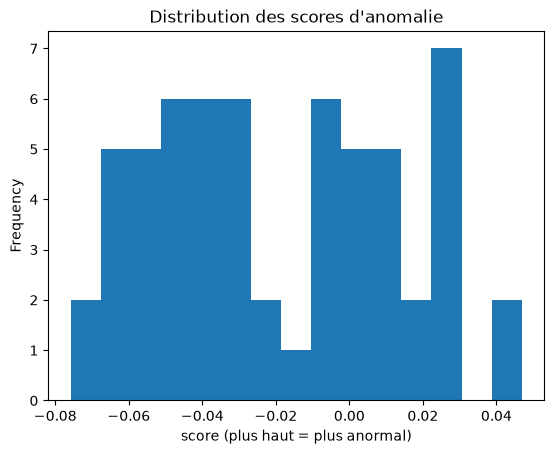

Nombre d'alertes marquées anormales : 19 / 60


In [5]:
alertes_evaluables['score_anomalie'].plot(kind='hist', bins=15, title="Distribution des scores d'anomalie")
plt.xlabel("score (plus haut = plus anormal)")
plt.show()

print("Nombre d'alertes marquées anormales :", alertes_evaluables['est_anomalie'].sum(),
      "/", len(alertes_evaluables))

In [6]:
print("Nombre d'alertes marquées anormales :", alertes_evaluables['est_anomalie'].sum(), "/", len(alertes_evaluables))

Nombre d'alertes marquées anormales : 19 / 60


## 6. Vérification qualitative

À faire manuellement : ouvrir les 10 alertes au score le plus élevé (section 4) et vérifier
si elles correspondent à des cas qui semblent réellement suspects (valeur très supérieure au
seuil, type d'alerte rare, etc.).

## 7. Ce qu'il faut écrire dans le rapport de stage

- Le modèle est **non supervisé** : évaluation qualitative par inspection manuelle des scores
  les plus élevés, pas de vraies étiquettes "anomalie" disponibles.
- **Limite identifiée** : le dataset d'entraînement d'Emna ne couvre pas tous les cas du schéma
  réel — certains `type_alerte` (ex. `AUTH_FAILURE_SPIKE`) et équipements (`ARI-MW-014`,
  `TUN-SRV-NMS-01`) sont absents de son encodeur, donc exclus de cette évaluation. À signaler
  comme axe d'amélioration : réentraîner sur un dataset couvrant l'ensemble des types/équipements.
- Le score d'anomalie est pensé pour compléter le score de criticité du moteur de règles,
  pas le remplacer.